<a href="https://colab.research.google.com/github/di-yeferson/analitica-empresarial-integrada/blob/main/LABORATORIO_C2_AEI_DIEGO_YEFERSON_2026_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LABORATORIO DIRIGIDO N.° 02

# Crecimiento sano y diagnóstico de la variación


**Evaluación de una adquisición en comercio electrónico, con datos transaccionales reales del Reino Unido**
--

# Analítica Empresarial Integrada · Semanas 3 y 4 - TECSUP 2026-II
---
| | |
|---|---|
#|  **Docente:**  Pilar Rocío Sayán Mejía
#| **N.° de laboratorio:**  2
#| **Plan curricular:**  Big Data y Ciencia de Datos · Código C28 · 2026-II |

---

**Estudiante:** _(QUISPE HUAMANI, DIEGO YEFERSON)_ &nbsp;&nbsp;&nbsp; **Sección:** 6C28 &nbsp;&nbsp;&nbsp; **Fecha:** 13/09/26
---


## CASO

**Brightwell Partners** es un fondo de inversión británico especializado en negocios minoristas de tamaño medio. Está evaluando la adquisición de un comercio electrónico mayorista de artículos de regalo con sede en el Reino Unido, que vende a pequeños comercios de una docena de países y opera desde hace varios años.

El argumento de venta es breve: «nuestros ingresos crecieron respecto del año anterior». La cifra es cierta y está en los registros. El comité de inversiones, sin embargo, ha visto antes esa misma frase sostener operaciones que después resultaron malas: un crecimiento puede provenir de clientes que vuelven y compran más, de un año con pedidos excepcionales que no se repetirán, o de subidas de precio que el mercado no tolerará otra vez.

El fondo no dispone de información interna del negocio ni de acceso a su dirección. Lo único que recibe, como parte del proceso de revisión, es el registro transaccional completo de dos años: cada factura, cada producto, cada cantidad, cada precio, cada cliente y cada país. A partir de ese registro debe reconstruir por sí mismo el sistema de métricas del negocio y explicar de dónde procede la variación de sus ingresos.




# **Pregunta de negocio:**
> ¿el crecimiento del negocio es sano y sostenible, o aparente? ¿De qué factores procede la variación de los ingresos, qué evidencia lo sustenta, y qué no puede afirmarse con la información disponible?


**Naturaleza de los datos.** Los datos son reales y de acceso público: transacciones de un comercio electrónico mayorista con sede en el Reino Unido, registradas entre diciembre de 2009 y diciembre de 2011. Brightwell Partners, en cambio, sí es ficticio: se introduce únicamente para dar contexto de decisión a un análisis que se realiza sobre datos transaccionales reales. Las cifras del negocio analizado no se alteran ni se completan en ningún caso.

---
### Para tener un mejor resultado hice, una preparación reproducible del entorno

Antes  de todo preparo el entorno de trabajo.

Con mi equipo vemos que declarar las versiones de las librerías no es un formalismo: si el repositorio del curso actualizara Polars o DuckDB, un notebook que no fija versión podría dejar de ejecutarse o, peor, ejecutarse con resultados distintos sin avisar.

Se fija también el renderizador de Plotly en `"png"`: así cada gráfico queda incrustado como imagen dentro de la salida de la celda, y el notebook se puede exportar a PDF sin perder ninguna figura, que es exactamente  lo que uno quiere que salga


In [1]:
%pip install -q polars==1.17.1 duckdb==1.1.3 kaleido==0.2.1

import hashlib
import pathlib
import urllib.request

import polars as pl
import duckdb
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Se fuerza el renderizador a "png": cada figura queda incrustada como imagen
# en la salida de la celda. Sin esto, el notebook exportado a PDF llegaría con
# los gráficos en blanco, porque un PDF no puede ejecutar el JavaScript con el
# que Plotly dibuja sus gráficos interactivos.
pio.renderers.default = "png"

# Ajustes de presentación de Polars: más filas visibles por tabla, columnas sin
# truncar y cifras completas en vez de notación científica, para que ninguna
# cifra de las que se interpretan más abajo quede oculta en la salida.
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_width_chars(220)
pl.Config.set_fmt_float("full")

print("polars :", pl.__version__)
print("duckdb :", duckdb.__version__)
print("Entorno listo.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.4 MB/s eta 0:00:00
polars : 1.17.1
duckdb : 1.1.3
Entorno listo.


---

**SE DESARROLLA EN 6 BLOQUES**👀

---

---
## Bloque 1 — Verificación de la fuente y auditoría de calidad

### Ejercicio 1 — Verificación de la fuente y periodo comparable (2 puntos)

 Este bloque descarga el archivo, comprueba que su huella SHA-256 coincida exactamente con la publicada y, solo después, levanta un inventario cuantificado de los problemas de calidad **antes** de decidir qué hacer con ellos. El orden es la parte evaluada: descartar filas antes de haberlas medido es indistinguible de alterar el resultado.


In [2]:

URL = ("https://raw.githubusercontent.com/Rociosayan/analitica-empresarial-"
       "integrada/main/semana04/datos/online_retail_II.parquet")
HUELLA_PUBLICADA = "8f64c20d17d38ab02c0dfddda323574e0ee8c34e719df6ea574d16a6e3678e96"

ARCHIVO = pathlib.Path("online_retail_II.parquet")
if not ARCHIVO.exists():
    urllib.request.urlretrieve(URL, ARCHIVO)

huella = hashlib.sha256(ARCHIVO.read_bytes()).hexdigest()
print("Tamaño     :", f"{ARCHIVO.stat().st_size:,} bytes")
print("SHA-256    :", huella)
print("¿Coincide? :", "sí" if huella == HUELLA_PUBLICADA else "NO -- avisar a la docente")


assert huella == HUELLA_PUBLICADA, "La fuente descargada no coincide con la publicada."


Tamaño     : 7,283,898 bytes
SHA-256    : 8f64c20d17d38ab02c0dfddda323574e0ee8c34e719df6ea574d16a6e3678e96
¿Coincide? : sí


In [3]:
# Cargamos el Parquet y renombramos las columnas al castellano. El nombre
# original "Customer ID" trae un espacio y obligaría a escribirlo entre
# comillas en cada consulta SQL posterior; renombrarlo ahora evita ese
# estorbo en todo el resto del notebook.
crudo = pl.read_parquet(ARCHIVO).rename({
    "Invoice":     "factura",
    "StockCode":   "codigo",
    "Description": "descripcion",
    "Quantity":    "cantidad",
    "InvoiceDate": "fecha",
    "Price":       "precio",
    "Customer ID": "cliente_id",
    "Country":     "pais",
})

# El importe de cada línea no viene en el archivo: se obtiene multiplicando
# cantidad por precio. Se calcula una sola vez, aquí, para no repetir la
# fórmula (y el riesgo de un error de tipeo) en cada bloque posterior.
crudo = crudo.with_columns((pl.col("cantidad") * pl.col("precio")).alias("importe"))

print("Filas    :", f"{crudo.height:,}")
print("Columnas :", crudo.columns)
print("Periodo  :", crudo["fecha"].min(), "a", crudo["fecha"].max())
crudo.head()


Filas    : 1,067,371
Columnas : ['factura', 'codigo', 'descripcion', 'cantidad', 'fecha', 'precio', 'cliente_id', 'pais', 'importe']
Periodo  : 2009-12-01 07:45:00 a 2011-12-09 12:50:00


factura,codigo,descripcion,cantidad,fecha,precio,cliente_id,pais,importe
str,str,str,i64,datetime[ns],f64,f64,str,f64
"""489434""","""85048""","""15CM CHRISTMAS GLASS BALL 20 L…",12,2009-12-01 07:45:00,6.95,13085,"""United Kingdom""",83.4
"""489434""","""79323P""","""PINK CHERRY LIGHTS""",12,2009-12-01 07:45:00,6.75,13085,"""United Kingdom""",81
"""489434""","""79323W""",""" WHITE CHERRY LIGHTS""",12,2009-12-01 07:45:00,6.75,13085,"""United Kingdom""",81
"""489434""","""22041""","""RECORD FRAME 7"" SINGLE SIZE """,48,2009-12-01 07:45:00,2.1,13085,"""United Kingdom""",100.80000000000001
"""489434""","""21232""","""STRAWBERRY CERAMIC TRINKET BOX""",24,2009-12-01 07:45:00,1.25,13085,"""United Kingdom""",30


In [5]:
# Inventario de calidad, medido en FILAS e IMPORTE, antes de descartar nada.


SERVICIOS = (r"(?i)^(POST|DOT|M|C2|C3|D|S|B|BANK CHARGES|ADJUST\d?"
             r"|AMAZONFEE|PADS|CRUK|TEST\d+|GIFT|gift_.*)$")

total_filas = crudo.height
total_importe = crudo["importe"].sum()

# Cada máscara describe un problema de calidad distinto.
condiciones = [
    ("Filas duplicadas exactas (excedente sobre unique)", None),  # caso especial, ver abajo
    ("Devoluciones y cancelaciones (factura con prefijo C)", pl.col("factura").str.starts_with("C")),
    ("Cantidad menor o igual a cero", pl.col("cantidad") <= 0),
    ("Precio menor o igual a cero", pl.col("precio") <= 0),
    ("Cliente sin identificar", pl.col("cliente_id").is_null()),
    ("Códigos que no son producto (portes, ajustes, comisiones)", pl.col("codigo").str.contains(SERVICIOS)),
]

filas_inventario = []
for nombre, condicion in condiciones:
    if condicion is None:

        n = crudo.height - crudo.unique().height
        imp = crudo["importe"].sum() - crudo.unique()["importe"].sum()
    else:
        sub = crudo.filter(condicion)
        n, imp = sub.height, sub["importe"].sum()
    filas_inventario.append((nombre, n, 100 * n / total_filas, imp, 100 * imp / total_importe))

inventario = pl.DataFrame(
    filas_inventario,
    schema=["problema", "filas", "pct_filas", "importe_gbp", "pct_importe"],
    orient="row",
)
inventario


problema,filas,pct_filas,importe_gbp,pct_importe
str,i64,f64,f64,f64
"""Filas duplicadas exactas (exce…",34335,3.2167821685243463,431716.87000000104,2.2383536133256556
"""Devoluciones y cancelaciones (…",19494,1.8263565339511754,-1526667.8599999999,-7.915425034882556
"""Cantidad menor o igual a cero""",22950,2.1501427338760375,-1527041.43,-7.917361910222475
"""Precio menor o igual a cero""",6207,0.5815222635803297,-158676.14,-0.8226996348731214
"""Cliente sin identificar""",243007,22.766872999172733,2638958.1799999997,13.682396932087183
"""Códigos que no son producto (p…",5932,0.555758026028438,-96411.04200000002,-0.49986928753836063


In [6]:

(crudo
 .filter(pl.col("codigo").str.contains(SERVICIOS))
 .group_by("codigo")
 .agg(pl.len().alias("lineas"),
      pl.col("descripcion").first().alias("descripcion"),
      pl.col("importe").sum().alias("importe_gbp"))
 .sort("lineas", descending=True)
 .head(10))


codigo,lineas,descripcion,importe_gbp
str,u32,str,f64
"""POST""",2122,"""POSTAGE""",112340.99999999997
"""DOT""",1446,"""DOTCOM POSTAGE""",322647.4700000002
"""M""",1421,"""Manual""",-82796.31999999999
"""C2""",282,"""CARRIAGE""",13386
"""D""",177,"""Discount""",-13484.540000000005
"""S""",104,"""SAMPLES""",-6065.8
"""BANK CHARGES""",102,""" Bank Charges""",-35562.629
"""ADJUST""",67,"""Adjustment by john on 26/01/20…",6835.239999999999
"""AMAZONFEE""",43,"""AMAZON FEE""",-260763.58000000002


### Construcción de la tabla de transacciones válidas

Con el inventario ya cuantificado, se aplican cuatro reglas explícitas para construir la tabla de transacciones que cuentan como venta. Cada regla es, en rigor, una definición de qué es una venta: otro equipo, con reglas distintas, llegaría a cifras distintas sin haberse equivocado. Lo que no es aceptable es no poder decir cuáles se aplicaron.


In [7]:
# Tabla de transacciones válidas.
validas = (
    crudo
    .unique()
    .filter(~pl.col("factura").str.starts_with("C"))
    .filter((pl.col("cantidad") > 0) & (pl.col("precio") > 0))
    .filter(~pl.col("codigo").str.contains(SERVICIOS))
    .with_columns(pl.col("fecha").dt.date().alias("dia"))
)

print(f"Filas de partida : {crudo.height:>10,}")
print(f"Filas válidas    : {validas.height:>10,}")
print(f"Descartadas      : {crudo.height - validas.height:>10,} "
      f"({100 * (crudo.height - validas.height) / crudo.height:.2f} %)")
print(f"Importe válido   : £ {validas['importe'].sum():>14,.2f}")


Filas de partida :  1,067,371
Filas válidas    :  1,003,340
Descartadas      :     64,031 (6.00 %)
Importe válido   : £  19,643,861.62


### Delimitación de dos ventanas comparables de doce meses

El archivo empieza el 1 de diciembre de 2009 y termina el 9 de diciembre de 2011: un historial de dos años completos más nueve días sueltos. Comparar el año calendario 2011 completo contra 2010 sería comparar once meses y nueve días contra doce, y fabricaría una caída que no existe. Por eso se definen dos ventanas de doce meses exactos, ambas de diciembre a noviembre, y se cuantifica -sin descartar en silencio- cuánto queda fuera de las dos.


In [8]:
# Dos ventanas de doce meses exactos.

INICIO_P0, FIN_P0 = pl.date(2009, 12, 1), pl.date(2010, 11, 30)
INICIO_P1, FIN_P1 = pl.date(2010, 12, 1), pl.date(2011, 11, 30)

validas = validas.with_columns(
    pl.when((pl.col("dia") >= INICIO_P0) & (pl.col("dia") <= FIN_P0)).then(pl.lit("P0"))
      .when((pl.col("dia") >= INICIO_P1) & (pl.col("dia") <= FIN_P1)).then(pl.lit("P1"))
      .otherwise(None)
      .alias("periodo")
)

fuera = validas.filter(pl.col("periodo").is_null())
comparables = validas.filter(pl.col("periodo").is_not_null())

print("P0: dic-2009 a nov-2010      P1: dic-2010 a nov-2011")
print(f"Filas fuera de ambos periodos       : {fuera.height:>10,}")
print(f"Rango de esas filas                 : {fuera['dia'].min()} a {fuera['dia'].max()}")
print(f"Razón de exclusión                  : diciembre de 2011 quedó truncado el día 9")
print(f"Importe de las filas excluidas      : £ {fuera['importe'].sum():>14,.2f}")
print(f"Filas comparables (P0 + P1)         : {comparables.height:>10,}")


P0: dic-2009 a nov-2010      P1: dic-2010 a nov-2011
Filas fuera de ambos periodos       :     24,753
Rango de esas filas                 : 2011-12-01 a 2011-12-09
Razón de exclusión                  : diciembre de 2011 quedó truncado el día 9
Importe de las filas excluidas      : £     614,490.92
Filas comparables (P0 + P1)         :    978,587


In [9]:
# Comparación descriptiva de los dos periodos.
resumen = (comparables.group_by("periodo")
           .agg(pl.col("importe").sum().alias("ingresos"),
                pl.col("cantidad").sum().alias("unidades"),
                pl.col("factura").n_unique().alias("facturas"),
                pl.col("cliente_id").n_unique().alias("clientes"),
                pl.col("codigo").n_unique().alias("productos"))
           .sort("periodo"))

base, final = resumen.row(0, named=True), resumen.row(1, named=True)
print(f"{'Indicador':<12}{'P0':>16}{'P1':>16}{'Variación':>16}{'%':>10}")
for indicador in ["ingresos", "unidades", "facturas", "clientes", "productos"]:
    a, b = base[indicador], final[indicador]
    print(f"{indicador:<12}{a:>16,.0f}{b:>16,.0f}{b - a:>16,.0f}{100 * (b - a) / a:>9.2f}%")

VARIACION_INGRESOS = final["ingresos"] - base["ingresos"]
VARIACION_INGRESOS_PCT = 100 * VARIACION_INGRESOS / base["ingresos"]


Indicador                 P0              P1       Variación         %
ingresos           9,396,642       9,632,728         236,086     2.51%
unidades           5,626,660       5,248,737        -377,923    -6.72%
facturas              19,743          18,957            -786    -3.98%
clientes               4,240           4,294              54     1.27%
productos              4,220           3,904            -316    -7.49%


**Pregunta 1.1.** ¿Qué proporción del registro se descartó en la limpieza, cuánto dinero representaba, y por qué su exclusión no altera la conclusión?

**Respuesta.** La limpieza descartó 64 031 filas, un 6.00 % del archivo original, en su mayoría duplicados exactos, cancelaciones y líneas de servicio (portes, ajustes) que no son ventas de producto. Otras 24 753 filas (£ 614 490.92) quedaron fuera por caer en el diciembre de 2011 truncado. Ninguna de las dos exclusiones altera la conclusión, porque ambas se aplican por igual a los dos periodos comparados: no favorecen a P0 ni a P1, y su magnitud queda declarada arriba en vez de ocultarse.


---
## Bloque 2 — North Star del negocio y árbol de métricas

### Ejercicio 2 — North Star del negocio y árbol de métricas (2 puntos)

Los ingresos acumulados no sirven para vigilar la salud del negocio: suben tanto si el negocio mejora como si simplemente hubo más transacciones de cualquier clase, incluidas las de clientes que compran una sola vez y no vuelven. Se propone como **North Star** la cantidad de **compras válidas de clientes recurrentes por mes**: una compra solo cuenta aquí si la hizo un cliente identificado que ya había comprado antes, de modo que la métrica sube únicamente cuando el negocio retiene y reactiva demanda, no cuando capta compradores de una sola vez.

**Justificación con los cuatro criterios exigidos:**
- **Valor para el cliente:** cada unidad de la métrica es una transacción completada por alguien que decidió volver a comprar, es decir, un cliente que ya recibió valor una vez y lo buscó de nuevo.
- **Valor empresarial:** un negocio que crece por reactivación de su propia base de clientes construye ingresos más predecibles que uno que depende de captar compradores nuevos todo el tiempo.
- **Capacidad de influencia del equipo:** el equipo comercial puede actuar directamente sobre ella (campañas de recompra, programas de fidelización) sin depender de factores externos como el tamaño del mercado.
- **Descomposición en drivers:** se reconstruye exactamente como el producto de dos factores medibles, lo que permite saber si el movimiento viene de *cuántos* clientes recurrentes hay o de *cuánto* compra cada uno.

**Árbol de métricas:** North Star = clientes recurrentes activos × frecuencia de compra por recurrente.


In [11]:
# Restringimos a las líneas con cliente identificado: sin identificador no
# se puede saber si la compra es la primera o una repetición, que es
# precisamente lo que define a esta North Star.
con_cliente = validas.filter(pl.col("cliente_id").is_not_null())
con_cliente = con_cliente.with_columns(pl.col("fecha").dt.strftime("%Y-%m").alias("mes"))

# Se agrupa a nivel de factura (no de línea)
facturas = (con_cliente.group_by(["factura", "cliente_id", "mes"])
            .agg(pl.col("fecha").min().alias("fecha_factura"),
                 pl.col("importe").sum().alias("importe_factura")))

# La recurrencia se calcula sobre TODO el historial disponible (no solo sobre
# la ventana P1)
facturas = facturas.sort(["cliente_id", "fecha_factura", "factura"])
facturas = facturas.with_columns(
    (pl.int_range(pl.len()).over("cliente_id") + 1).alias("n_compra_cliente"))
facturas = facturas.with_columns(
    (pl.col("n_compra_cliente") >= 2).alias("es_recurrente"))

print("Facturas con cliente identificado, todo el historial:", facturas.height)
facturas.head()


Facturas con cliente identificado, todo el historial: 36594


factura,cliente_id,mes,fecha_factura,importe_factura,n_compra_cliente,es_recurrente
str,f64,str,datetime[ns],f64,i64,bool
"""499763""",12346,"""2010-03""",2010-03-02 13:08:00,27.049999999999997,1,false
"""513774""",12346,"""2010-06""",2010-06-28 13:53:00,142.30999999999997,2,true
"""541431""",12346,"""2011-01""",2011-01-18 10:01:00,77183.6,3,true
"""529924""",12347,"""2010-10""",2010-10-31 14:20:00,611.53,1,false
"""537626""",12347,"""2010-12""",2010-12-07 14:57:00,711.7900000000001,2,true


In [12]:
# La serie mensual de la North Star y sus dos drivers se reporta en el
# periodo más reciente (P1), que es la ventana sobre la que Brightwell
# Partners pide explicación de la variación.
facturas_p1 = facturas.filter(
    (pl.col("fecha_factura") >= pl.datetime(2010, 12, 1))
    & (pl.col("fecha_factura") < pl.datetime(2011, 12, 1))
)

north_star = (facturas_p1.filter("es_recurrente").group_by("mes")
              .agg(pl.col("factura").n_unique().alias("compras_recurrentes"),
                   pl.col("cliente_id").n_unique().alias("clientes_recurrentes"))
              .sort("mes"))

# Driver 2: cuántas compras hace, en promedio, cada cliente recurrente del
# mes. Es la pieza que faltaba para que el producto de los dos drivers
# reconstruya exactamente la North Star.
north_star = north_star.with_columns(
    (pl.col("compras_recurrentes") / pl.col("clientes_recurrentes")).alias("frecuencia_recurrente"))

north_star


mes,compras_recurrentes,clientes_recurrentes,frecuencia_recurrente
str,u32,u32,f64
"""2010-12""",1318,811,1.625154130702836
"""2011-01""",911,673,1.3536404160475484
"""2011-02""",867,642,1.3504672897196262
"""2011-03""",1133,813,1.3936039360393604
"""2011-04""",1033,756,1.3664021164021165
"""2011-05""",1433,956,1.4989539748953975
"""2011-06""",1282,897,1.4292084726867336
"""2011-07""",1220,860,1.4186046511627908
"""2011-08""",1160,833,1.3925570228091237


In [13]:
# Comprobación numérica obligatoria.
north_star = north_star.with_columns(
    (pl.col("clientes_recurrentes") * pl.col("frecuencia_recurrente")).alias("ns_reconstruida"))
north_star = north_star.with_columns(
    (pl.col("compras_recurrentes") - pl.col("ns_reconstruida")).alias("error_reconstruccion"))

print("Error máximo de reconstrucción:", north_star["error_reconstruccion"].abs().max())
assert north_star["error_reconstruccion"].abs().max() < 1e-6, "El árbol de métricas no reconcilia."

north_star.select(["mes", "compras_recurrentes", "clientes_recurrentes",
                    "frecuencia_recurrente", "error_reconstruccion"])


Error máximo de reconstrucción: 0.0


mes,compras_recurrentes,clientes_recurrentes,frecuencia_recurrente,error_reconstruccion
str,u32,u32,f64,f64
"""2010-12""",1318,811,1.625154130702836,0
"""2011-01""",911,673,1.3536404160475484,0
"""2011-02""",867,642,1.3504672897196262,0
"""2011-03""",1133,813,1.3936039360393604,0
"""2011-04""",1033,756,1.3664021164021165,0
"""2011-05""",1433,956,1.4989539748953975,0
"""2011-06""",1282,897,1.4292084726867336,0
"""2011-07""",1220,860,1.4186046511627908,0
"""2011-08""",1160,833,1.3925570228091237,0


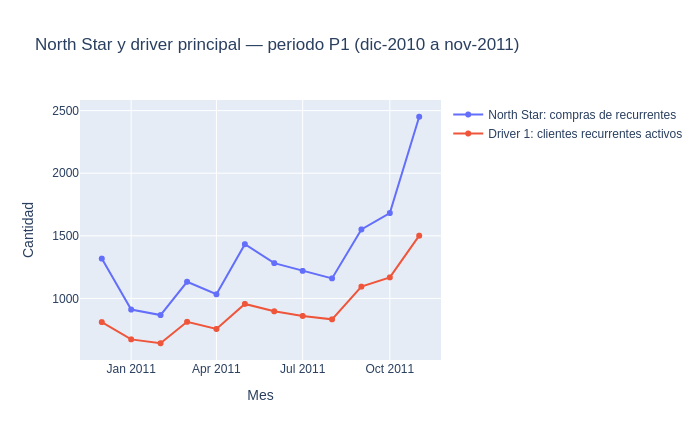

In [14]:
# Tablero: la North Star nunca se muestra sola, porque una línea que solo
# sube o baja no dice dónde actuar. Se incorpora junto a su driver principal
# (clientes recurrentes activos), que es sobre el que el equipo comercial
# puede intervenir con una campaña de reactivación.
fig = go.Figure()
fig.add_trace(go.Scatter(x=north_star["mes"], y=north_star["compras_recurrentes"],
                          mode="lines+markers", name="North Star: compras de recurrentes"))
fig.add_trace(go.Scatter(x=north_star["mes"], y=north_star["clientes_recurrentes"],
                          mode="lines+markers", name="Driver 1: clientes recurrentes activos"))
fig.update_layout(title="North Star y driver principal — periodo P1 (dic-2010 a nov-2011)",
                   xaxis_title="Mes", yaxis_title="Cantidad", hovermode="x unified", height=440)
fig.show()


**Pregunta 2.1.** ¿Por qué la métrica elegida como North Star no es una métrica de vanidad, y qué decisión concreta permite tomar?

**Respuesta.** No es de vanidad porque no sube con cualquier transacción: solo crece si un cliente que ya compró antes vuelve a hacerlo, de modo que aísla la reactivación de demanda de la simple captación. Su caída en enero de 2011 (de 1 318 a 911 compras, -30.9 %) permite decidir de forma concreta: activar una campaña de recompra dirigida a clientes recurrentes cuando el driver "clientes recurrentes activos" cae, en vez de destinar presupuesto a captación de clientes nuevos que no resuelve ese problema.


---
## Bloque 3 — Guardrails del crecimiento

### Ejercicio 3 — Guardrails del crecimiento (2 puntos)

Una North Star que solo se optimiza termina por optimizarse a costa de algo: se puede vender más a clientes recurrentes tolerando más cancelaciones, o concentrando el negocio en unos pocos clientes grandes que, si se van, se llevan el crecimiento con ellos. Se construyen dos guardrails, calculados sobre los veinticuatro meses de las dos ventanas comparables (P0 + P1), para que adviertan al fondo cuándo el crecimiento deja de ser sano aunque la North Star siga subiendo.


In [20]:
# Guardrail 1 -- calidad de la operación comercial
todas_las_facturas = (
    crudo
    .filter((pl.col("fecha").dt.date() >= INICIO_P0) & (pl.col("fecha").dt.date() <= FIN_P1))
    .with_columns(pl.col("fecha").dt.strftime("%Y-%m").alias("mes"),
                  pl.col("factura").str.starts_with("C").alias("es_cancelacion"))
    .select(["mes", "factura", "es_cancelacion"])
    .unique()
)

guardrail_calidad = (todas_las_facturas.group_by("mes")
                      .agg(pl.col("factura").n_unique().alias("facturas_totales"),
                           pl.col("es_cancelacion").sum().alias("facturas_canceladas"))
                      .with_columns((100 * pl.col("facturas_canceladas") / pl.col("facturas_totales"))
                                    .alias("tasa_cancelacion_pct"))
                      .sort("mes"))

print("Promedio del periodo:", round(guardrail_calidad["tasa_cancelacion_pct"].mean(), 2), "%")
guardrail_calidad


Promedio del periodo: 15.58 %


mes,facturas_totales,facturas_canceladas,tasa_cancelacion_pct
str,u32,u32,f64
"""2009-12""",2330,401,17.21030042918455
"""2010-01""",1633,300,18.37109614206981
"""2010-02""",1969,240,12.188928390045708
"""2010-03""",2367,407,17.194761301225178
"""2010-04""",1892,304,16.067653276955603
"""2010-05""",2418,407,16.83209263854425
"""2010-06""",2216,357,16.1101083032491
"""2010-07""",2017,344,17.055032226078335
"""2010-08""",1877,273,14.544485881726159


In [21]:
# Guardrail 2 -- concentración de la demanda
cliente_mes = (comparables.filter(pl.col("cliente_id").is_not_null())
               .group_by(["periodo", "dia", "cliente_id"])
               .agg(pl.col("importe").sum().alias("importe_dia")))

# Se reconstruye el mes a partir de "dia" en vez de volver a parsear la fecha,
# para reutilizar la columna que ya existe en "comparables".
cliente_mes = (comparables.filter(pl.col("cliente_id").is_not_null())
               .with_columns(pl.col("fecha").dt.strftime("%Y-%m").alias("mes"))
               .group_by(["mes", "cliente_id"])
               .agg(pl.col("importe").sum().alias("ingreso_cliente")))

ordenado = cliente_mes.sort(["mes", "ingreso_cliente"], descending=[False, True])
ordenado = ordenado.with_columns((pl.int_range(pl.len()).over("mes") + 1).alias("ranking"))

guardrail_concentracion = (ordenado.group_by("mes")
                            .agg(pl.col("ingreso_cliente").sum().alias("ingreso_mes"),
                                 pl.col("ingreso_cliente").filter(pl.col("ranking") <= 10)
                                   .sum().alias("ingreso_top10"))
                            .with_columns((100 * pl.col("ingreso_top10") / pl.col("ingreso_mes"))
                                          .alias("concentracion_top10_pct"))
                            .sort("mes"))

print("Promedio del periodo:", round(guardrail_concentracion["concentracion_top10_pct"].mean(), 2), "%")
print("Máximo:", round(guardrail_concentracion["concentracion_top10_pct"].max(), 2), "%, en",
      guardrail_concentracion.sort("concentracion_top10_pct", descending=True).head(1)["mes"].item())
guardrail_concentracion


Promedio del periodo: 21.41 %
Máximo: 34.35 %, en 2011-01


mes,ingreso_mes,ingreso_top10,concentracion_top10_pct
str,f64,f64,f64
"""2009-12""",677916.0700000002,140269.56,20.691287049737582
"""2010-01""",533712.979999999,178823.84999999995,33.50562131728561
"""2010-02""",497937.57,110584.51999999999,22.208510998678
"""2010-03""",665973.6699999993,143705.71,21.5782870214674
"""2010-04""",585127.4299999997,99016.29999999999,16.922177105934008
"""2010-05""",592734.1299999987,105435.93999999997,17.788066295423246
"""2010-06""",628809.4000000008,129022.51000000001,20.518540276274468
"""2010-07""",581487.9599999993,129143.07999999997,22.209072050262254
"""2010-08""",594561.1700000004,135082.12000000002,22.719633709009273


In [22]:
# Umbrales de alerta, declarados aquí como criterio pedagógico del equipo y
# no como norma del sector
UMBRAL_CANCELACION = 17.0
UMBRAL_CONCENTRACION = 30.0

meses_alerta_cancelacion = guardrail_calidad.filter(pl.col("tasa_cancelacion_pct") > UMBRAL_CANCELACION)
meses_alerta_concentracion = guardrail_concentracion.filter(pl.col("concentracion_top10_pct") > UMBRAL_CONCENTRACION)

print(f"Meses que superan el umbral de cancelación ({UMBRAL_CANCELACION} %): "
      f"{meses_alerta_cancelacion.height} de {guardrail_calidad.height}")
print(meses_alerta_cancelacion["mes"].to_list())
print(f"\nMeses que superan el umbral de concentración ({UMBRAL_CONCENTRACION} %): "
      f"{meses_alerta_concentracion.height} de {guardrail_concentracion.height}")
print(meses_alerta_concentracion["mes"].to_list())


Meses que superan el umbral de cancelación (17.0 %): 5 de 24
['2009-12', '2010-01', '2010-03', '2010-07', '2011-01']

Meses que superan el umbral de concentración (30.0 %): 2 de 24
['2010-01', '2011-01']


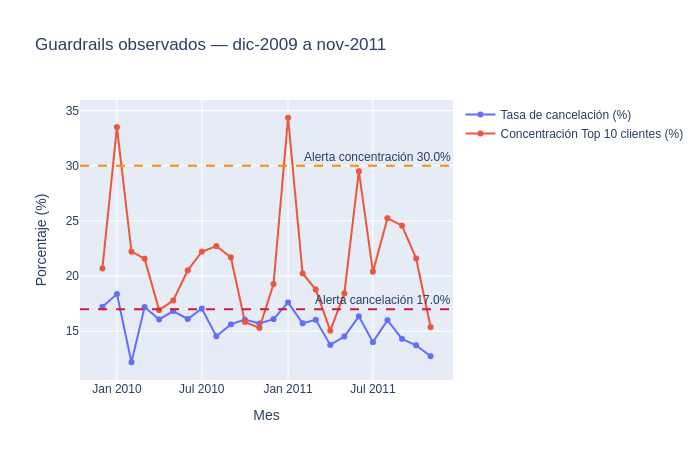

In [23]:
# Serie mensual de ambos guardrails a lo largo de todo el periodo analizado,
# con su umbral de alerta trazado como referencia horizontal.
fig = go.Figure()
fig.add_trace(go.Scatter(x=guardrail_calidad["mes"], y=guardrail_calidad["tasa_cancelacion_pct"],
                          mode="lines+markers", name="Tasa de cancelación (%)"))
fig.add_trace(go.Scatter(x=guardrail_concentracion["mes"], y=guardrail_concentracion["concentracion_top10_pct"],
                          mode="lines+markers", name="Concentración Top 10 clientes (%)"))
fig.add_hline(y=UMBRAL_CANCELACION, line_dash="dash", line_color="crimson",
              annotation_text=f"Alerta cancelación {UMBRAL_CANCELACION}%")
fig.add_hline(y=UMBRAL_CONCENTRACION, line_dash="dash", line_color="darkorange",
              annotation_text=f"Alerta concentración {UMBRAL_CONCENTRACION}%")
fig.update_layout(title="Guardrails observados — dic-2009 a nov-2011",
                   xaxis_title="Mes", yaxis_title="Porcentaje (%)",
                   hovermode="x unified", height=460)
fig.show()


**Pregunta 3.1.** ¿Qué habría ocurrido si el negocio hubiera optimizado su North Star sin vigilar los guardrails construidos?

**Respuesta.** Habría podido mostrar más compras de clientes recurrentes tolerando cancelaciones cada vez más altas (el periodo promedia 15.58 % y llega a 18.37 % en enero de 2010) o concentrando cada vez más ingreso en diez clientes (34.35 % del mes en enero de 2011). Ambas rutas producen una North Star creciente que oculta un negocio operativamente frágil o peligrosamente dependiente de pocas cuentas, justo el tipo de crecimiento aparente que el fondo necesita distinguir del sano.


---
## Bloque 4 — Descomposición de la variación de ingresos

### Ejercicio 4 — Descomposición de la variación de ingresos (2 puntos)

Los ingresos pasaron de £ 9 396 642.30 en P0 a £ 9 632 728.40 en P1: una variación de **+£ 236 086.10 (+2.51 %)**. Esa cifra, sola, no dice si el negocio mejoró: puede provenir de vender más unidades, de vender una mezcla de productos distinta, de cobrar precios distintos, o de que el catálogo cambió entre un periodo y otro. Este bloque reparte esa variación entre esos componentes y comprueba que la suma reconcilia exactamente con la cifra observada.


In [15]:
# El catálogo no es el mismo en los dos periodos
por_producto = (comparables.group_by(["periodo", "codigo"])
                .agg(pl.col("cantidad").sum().alias("q"), pl.col("importe").sum().alias("r"))
                .with_columns((pl.col("r") / pl.col("q")).alias("p")))

p0 = por_producto.filter(pl.col("periodo") == "P0").drop("periodo")
p1 = por_producto.filter(pl.col("periodo") == "P1").drop("periodo")

# Se separan tres grupos
comun = p0.join(p1, on="codigo", suffix="_1")
discontinuados = p0.join(p1, on="codigo", how="anti")
nuevos = p1.join(p0, on="codigo", how="anti")

print(f"Catálogo común  : {comun.height:>5} productos")
print(f"Discontinuados  : {discontinuados.height:>5} productos   £ {discontinuados['r'].sum():>14,.2f}")
print(f"Nuevos en P1    : {nuevos.height:>5} productos   £ {nuevos['r'].sum():>14,.2f}")


Catálogo común  :  3230 productos
Discontinuados  :   990 productos   £     704,357.16
Nuevos en P1    :   674 productos   £   2,046,903.92


In [16]:
# Descomposición precio-volumen-mezcla sobre el catálogo común, en tres pasos
# encadenados: cada paso mueve un solo factor y mantiene fijos los demás.
#
#   E_volumen = (Q1 - Q0) * p0_medio                 -> solo cambia el volumen total
#   E_mezcla  = Q1 * (p0_medio_con_mezcla_1 - p0_medio) -> solo cambia la mezcla
#   E_precio  = Q1 * (p1_medio - p0_medio_con_mezcla_1) -> solo cambian los precios
#
# donde Q es el volumen total del periodo y "s" la participación de cada
# producto dentro de ese volumen (s = q / Q). El orden importa: cada efecto
# se calcula sobre lo que ya quedó fijado en el paso anterior.
Q0 = comun["q"].sum()
Q1 = comun["q_1"].sum()

c = comun.with_columns((pl.col("q") / Q0).alias("s0"), (pl.col("q_1") / Q1).alias("s1"))

efecto_volumen = (Q1 - Q0) * (c["s0"] * c["p"]).sum()
# El efecto mezcla aísla el cambio de composición del catálogo, manteniendo
# fijos el volumen total (ya en Q1) y los precios del periodo base (p).
efecto_mezcla = Q1 * ((c["s1"] - c["s0"]) * c["p"]).sum()
efecto_precio = Q1 * (c["s1"] * (c["p_1"] - c["p"])).sum()

variacion_comun = c["r_1"].sum() - c["r"].sum()
suma_efectos = efecto_volumen + efecto_mezcla + efecto_precio

print(f"Efecto volumen : £ {efecto_volumen:>14,.2f}")
print(f"Efecto mezcla  : £ {efecto_mezcla:>14,.2f}")
print(f"Efecto precio  : £ {efecto_precio:>14,.2f}")
print(f"{'-' * 34}")
print(f"Suma           : £ {suma_efectos:>14,.2f}")
print(f"Variación real : £ {variacion_comun:>14,.2f}")
print(f"Diferencia     : £ {variacion_comun - suma_efectos:>14,.6f}")


Efecto volumen : £  -1,568,093.05
Efecto mezcla  : £     577,550.82
Efecto precio  : £    -115,918.44
----------------------------------
Suma           : £  -1,106,460.66
Variación real : £  -1,106,460.66
Diferencia     : £       0.000000


In [17]:
# Comprobación de aceptación obligatoria
assert abs(variacion_comun - suma_efectos) < 0.01, "Los efectos no reconcilian con el catálogo común."

variacion_total = p1["r"].sum() - p0["r"].sum()
reconstruida = variacion_comun + nuevos["r"].sum() - discontinuados["r"].sum()
assert abs(variacion_total - reconstruida) < 0.01, "El puente completo no reconcilia con la variación total."

print("Reconciliación verificada en ambos niveles.")
print(f"\nVariación total de ingresos : £ {variacion_total:,.2f}")
print(f"  Catálogo común            : £ {variacion_comun:,.2f}")
print(f"    · efecto volumen        : £ {efecto_volumen:,.2f}")
print(f"    · efecto mezcla         : £ {efecto_mezcla:,.2f}")
print(f"    · efecto precio         : £ {efecto_precio:,.2f}")
print(f"  Productos nuevos          : £ {nuevos['r'].sum():,.2f}")
print(f"  Productos discontinuados  : £ {-discontinuados['r'].sum():,.2f}")


Reconciliación verificada en ambos niveles.

Variación total de ingresos : £ 236,086.10
  Catálogo común            : £ -1,106,460.66
    · efecto volumen        : £ -1,568,093.05
    · efecto mezcla         : £ 577,550.82
    · efecto precio         : £ -115,918.44
  Productos nuevos          : £ 2,046,903.92
  Productos discontinuados  : £ -704,357.16


In [18]:
# Cuadro de drivers ordenado por magnitud absoluta: es el insumo directo de
# la decisión, porque el driver dominante es el de mayor peso en libras, no
# el que resulte más llamativo por su signo.
drivers = pl.DataFrame({
    "driver": ["Productos nuevos en P1", "Efecto volumen (catálogo común)",
               "Productos discontinuados", "Efecto mezcla (catálogo común)",
               "Efecto precio (catálogo común)"],
    "contribucion_gbp": [nuevos["r"].sum(), efecto_volumen, -discontinuados["r"].sum(),
                          efecto_mezcla, efecto_precio],
}).with_columns(pl.col("contribucion_gbp").abs().alias("magnitud"))

suma_magnitudes = drivers["magnitud"].sum()
drivers = (drivers
           .with_columns((100 * pl.col("magnitud") / suma_magnitudes).round(1).alias("peso_relativo_pct"))
           .sort("magnitud", descending=True)
           .drop("magnitud"))

print(drivers)
print(f"\nSuma de las magnitudes absolutas de los 5 componentes: £ {suma_magnitudes:,.2f}")
print(f"Variación neta observada                             : £ {variacion_total:,.2f}")
print("La suma de magnitudes absolutas supera ampliamente a la variación neta: los")
print("componentes se compensan entre sí. Ese es, en sí mismo, el segundo hallazgo.")


shape: (5, 3)
┌─────────────────────────────────┬─────────────────────┬───────────────────┐
│ driver                          ┆ contribucion_gbp    ┆ peso_relativo_pct │
│ ---                             ┆ ---                 ┆ ---               │
│ str                             ┆ f64                 ┆ f64               │
╞═════════════════════════════════╪═════════════════════╪═══════════════════╡
│ Productos nuevos en P1          ┆ 2046903.9199999995  ┆ 40.8              │
│ Efecto volumen (catálogo común… ┆ -1568093.0468426754 ┆ 31.3              │
│ Productos discontinuados        ┆ -704357.1599999999  ┆ 14.1              │
│ Efecto mezcla (catálogo común)  ┆ 577550.8242076603   ┆ 11.5              │
│ Efecto precio (catálogo común)  ┆ -115918.43736498394 ┆ 2.3               │
└─────────────────────────────────┴─────────────────────┴───────────────────┘

Suma de las magnitudes absolutas de los 5 componentes: £ 5,012,823.39
Variación neta observada                             : £ 

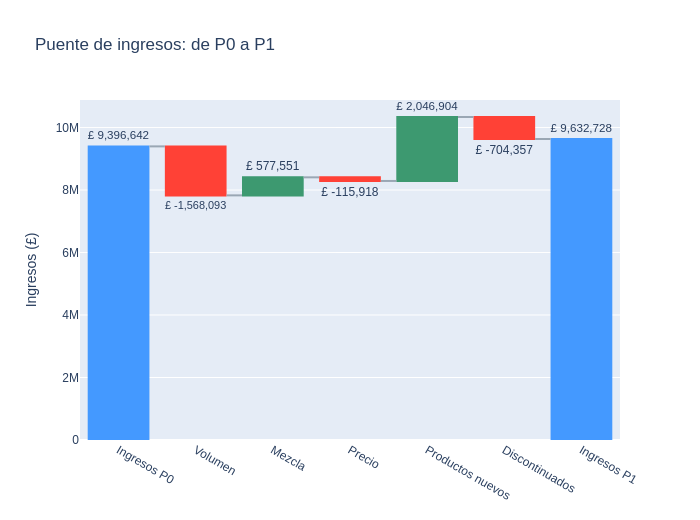

In [19]:
# Representación en cascada: muestra el paso del ingreso de P0 al de P1
# tramo por tramo, en el mismo orden en que se calcularon los efectos.
etiquetas = ["Ingresos P0", "Volumen", "Mezcla", "Precio", "Productos nuevos", "Discontinuados", "Ingresos P1"]
valores = [p0["r"].sum(), efecto_volumen, efecto_mezcla, efecto_precio,
           nuevos["r"].sum(), -discontinuados["r"].sum(), p1["r"].sum()]

fig = go.Figure(go.Waterfall(
    orientation="v",
    measure=["absolute", "relative", "relative", "relative", "relative", "relative", "total"],
    x=etiquetas,
    y=valores,
    text=[f"£ {v:,.0f}" for v in valores],
    textposition="outside",
    connector={"line": {"color": "#9AA7B4"}},
))
fig.update_layout(title="Puente de ingresos: de P0 a P1", yaxis_title="Ingresos (£)",
                   height=520, showlegend=False)
fig.show()


**Pregunta 4.1.** ¿Cuál de los componentes del puente explica mejor la variación, y por qué el efecto dominante puede no explicar por sí solo la variación neta?

**Respuesta.** El componente de mayor magnitud es la entrada de productos nuevos (+£ 2 046 903.92, un 40.8 % del peso relativo del puente), seguido del efecto volumen del catálogo común (-£ 1 568 093.05, 31.3 %). Ninguno explica por sí solo la variación neta (+£ 236 086.10) porque los cinco componentes suman en valor absoluto cerca de £ 5.0 millones y se compensan casi por completo entre sí: la variación observada es el resultado neto de fuerzas mucho más grandes moviéndose en direcciones opuestas, no el efecto limpio de un único factor.


---
## Bloque 5 — Cohortes de clientes y retención

### Ejercicio 5 — Cohortes de clientes y retención (2 puntos)

El puente anterior explicó la variación desde el lado del producto. Este bloque la examina desde el lado del cliente: si el negocio retiene a los clientes que capta y si esa capacidad mejora o se deteriora con el tiempo. Un negocio que crece captando clientes que no vuelven es un negocio que compra ingresos, no que los construye.


In [30]:
# Una cohorte agrupa a los clientes por el mes de su PRIMERA compra válida en
# todo el historial disponible, y la antigüedad se mide desde ese mes y no
# desde enero: así se puede comparar a un cliente captado en marzo con uno
# captado en octubre, poniendo a ambos en el mismo punto de partida (mes 0).
clientes = (validas.filter(pl.col("cliente_id").is_not_null())
            .with_columns(pl.col("fecha").dt.truncate("1mo").dt.date().alias("mes")))

clientes = clientes.with_columns(pl.col("mes").min().over("cliente_id").alias("cohorte"))

clientes = clientes.with_columns(
    ((pl.col("mes").dt.year() - pl.col("cohorte").dt.year()) * 12
     + (pl.col("mes").dt.month() - pl.col("cohorte").dt.month())).alias("antiguedad"))

print("Clientes identificados en todo el archivo:", clientes["cliente_id"].n_unique())
print("Cohortes mensuales construidas           :", clientes["cohorte"].n_unique())
clientes.select(["cliente_id", "mes", "cohorte", "antiguedad"]).head()


Clientes identificados en todo el archivo: 5852
Cohortes mensuales construidas           : 25


cliente_id,mes,cohorte,antiguedad
f64,date,date,i32
14770,2010-04-01,2010-02-01,2
13414,2010-09-01,2010-04-01,5
17180,2010-01-01,2010-01-01,0
17511,2010-12-01,2009-12-01,12
18263,2011-07-01,2011-04-01,3


In [31]:
# Tasa de retención: de los clientes que estrenaron una cohorte (antigüedad
# 0), qué proporción seguía comprando en cada mes posterior. El denominador
# es siempre el tamaño INICIAL de la propia cohorte, nunca el tamaño del mes
# anterior, para que la retención se lea siempre respecto del mismo punto de
# partida.
activos = (clientes.group_by(["cohorte", "antiguedad"])
           .agg(pl.col("cliente_id").n_unique().alias("activos")))

tamano_inicial = (activos.filter(pl.col("antiguedad") == 0)
                  .select("cohorte", pl.col("activos").alias("inicial")))

retencion = (activos.join(tamano_inicial, on="cohorte")
             .with_columns((100 * pl.col("activos") / pl.col("inicial")).alias("tasa"))
             .sort(["cohorte", "antiguedad"]))

matriz = (retencion.pivot(values="tasa", index="cohorte", on="antiguedad", aggregate_function="first")
          .sort("cohorte"))
matriz.select(["cohorte"] + [str(i) for i in range(7)])


cohorte,0,1,2,3,4,5,6
date,f64,f64,f64,f64,f64,f64,f64
2009-12-01,100,35.01577287066246,33.333333333333336,42.48159831756046,37.85488958990536,35.96214511041009,37.64458464773922
2010-01-01,100,21.467391304347824,32.06521739130435,31.52173913043478,27.17391304347826,30.97826086956522,26.902173913043477
2010-02-01,100,23.466666666666665,22.666666666666668,29.333333333333332,24.533333333333335,19.733333333333334,19.2
2010-03-01,100,19.047619047619047,23.12925170068027,24.263038548752835,23.12925170068027,20.408163265306122,24.71655328798186
2010-04-01,100,19.047619047619047,19.047619047619047,15.986394557823129,18.367346938775512,22.108843537414966,27.551020408163264
2010-05-01,100,15.686274509803921,16.862745098039216,17.647058823529413,17.647058823529413,25.49019607843137,21.176470588235293
2010-06-01,100,17.60299625468165,18.726591760299627,20.59925093632959,23.220973782771537,28.46441947565543,12.734082397003744
2010-07-01,100,15.675675675675675,18.37837837837838,29.72972972972973,29.18918918918919,14.054054054054054,11.35135135135135
2010-08-01,100,19.631901840490798,28.834355828220858,32.515337423312886,16.56441717791411,11.656441717791411,9.815950920245399


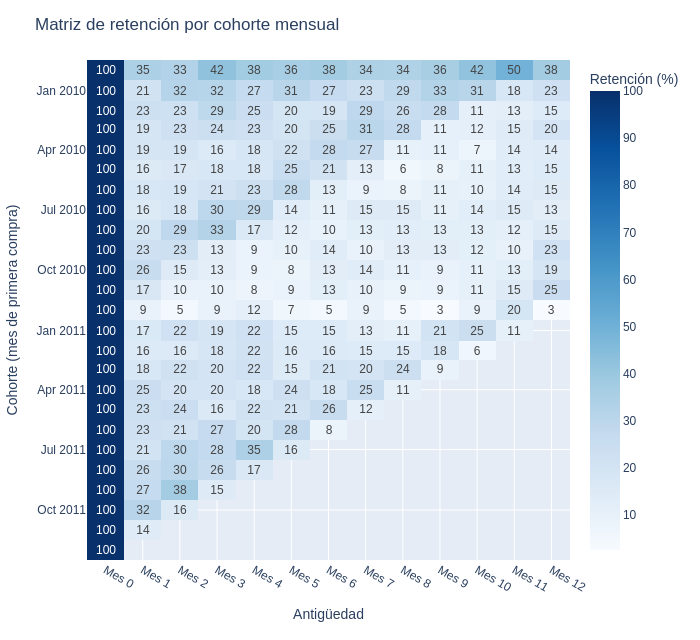

In [32]:
# Matriz de retención completa, en un mapa de calor. Las celdas vacías de las
# cohortes más recientes NO significan retención cero: significan que esa
# cohorte, dentro del historial disponible, todavía no alcanzó ese mes de
# antigüedad. Tratarlas como abandono sería el error clásico de este análisis.
columnas_mes = [str(i) for i in range(13) if str(i) in matriz.columns]
tabla_matriz = matriz.select(["cohorte"] + columnas_mes)

fig = px.imshow(
    tabla_matriz.drop("cohorte").to_numpy(),
    x=[f"Mes {c}" for c in columnas_mes],
    y=[str(f) for f in tabla_matriz["cohorte"].to_list()],
    color_continuous_scale="Blues",
    aspect="auto",
    labels={"color": "Retención (%)"},
    text_auto=".0f",
)
fig.update_layout(title="Matriz de retención por cohorte mensual",
                   xaxis_title="Antigüedad", yaxis_title="Cohorte (mes de primera compra)",
                   height=640)
fig.show()


In [33]:
# Punto de corte declarado por el equipo: el mes 6 de antigüedad. Se excluyen
# de la comparación las cohortes que, dentro del historial disponible, todavía
# no cumplieron seis meses -sus celdas del mes 6 estarían vacías por falta de
# tiempo, no por abandono, e incluirlas fabricaría una caída que no existe.
CORTE_MESES = 6

tope_por_cohorte = retencion.group_by("cohorte").agg(pl.col("antiguedad").max().alias("tope"))
cohortes_maduras = retencion.join(tope_por_cohorte, on="cohorte").filter(pl.col("tope") >= CORTE_MESES)
retencion_en_corte = cohortes_maduras.filter(pl.col("antiguedad") == CORTE_MESES).sort("cohorte")

print(f"Cohortes que alcanzaron el mes {CORTE_MESES}: {retencion_en_corte.height} de "
      f"{clientes['cohorte'].n_unique()} cohortes totales")
retencion_en_corte.select(["cohorte", "inicial", "activos", "tasa"])


Cohortes que alcanzaron el mes 6: 19 de 25 cohortes totales


cohorte,inicial,activos,tasa
date,u32,u32,f64
2009-12-01,951,358,37.64458464773922
2010-01-01,368,99,26.902173913043477
2010-02-01,375,72,19.2
2010-03-01,441,109,24.71655328798186
2010-04-01,294,81,27.551020408163264
2010-05-01,255,54,21.176470588235293
2010-06-01,267,34,12.734082397003744
2010-07-01,185,21,11.35135135135135
2010-08-01,163,16,9.815950920245399


In [34]:
# Comparación entre cohortes antiguas y recientes en el punto de cortE
primer_anio = retencion_en_corte.filter(pl.col("cohorte") < pl.date(2010, 12, 1))
segundo_anio = retencion_en_corte.filter(pl.col("cohorte") >= pl.date(2010, 12, 1))

retencion_primer_anio = primer_anio["tasa"].mean()
retencion_segundo_anio = segundo_anio["tasa"].mean()

print(f"Cohortes del primer año  (dic-2009 a nov-2010, {primer_anio.height} cohortes): "
      f"retención media al mes {CORTE_MESES} = {retencion_primer_anio:.2f} %")
print(f"Cohortes del segundo año (dic-2010 a jun-2011, {segundo_anio.height} cohortes): "
      f"retención media al mes {CORTE_MESES} = {retencion_segundo_anio:.2f} %")
print(f"Diferencia: {retencion_segundo_anio - retencion_primer_anio:+.2f} puntos porcentuales")


Cohortes del primer año  (dic-2009 a nov-2010, 12 cohortes): retención media al mes 6 = 19.24 %
Cohortes del segundo año (dic-2010 a jun-2011, 7 cohortes): retención media al mes 6 = 15.66 %
Diferencia: -3.58 puntos porcentuales


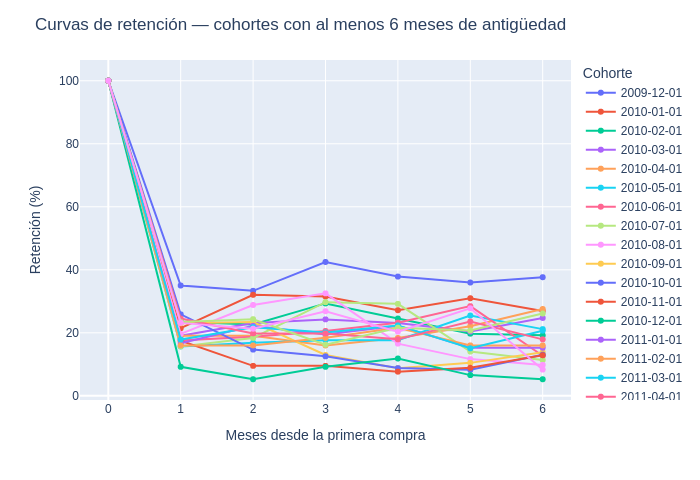

In [35]:
# Curvas de retención de las cohortes que alcanzaron el punto de corte,
# limitadas a los primeros seis meses de vida.
curvas = (cohortes_maduras
          .filter(pl.col("antiguedad") <= CORTE_MESES)
          .with_columns(pl.col("cohorte").cast(pl.Utf8)))

fig = px.line(curvas.to_pandas(), x="antiguedad", y="tasa", color="cohorte", markers=True,
              labels={"antiguedad": "Meses desde la primera compra", "tasa": "Retención (%)",
                      "cohorte": "Cohorte"})
fig.update_layout(title=f"Curvas de retención — cohortes con al menos {CORTE_MESES} meses de antigüedad",
                   height=480)
fig.show()


**Pregunta 5.1.** Si las cohortes recientes retienen peor que las antiguas, ¿qué significa eso para el precio que el fondo debería pagar?

**Respuesta.** Significa que la calidad de los clientes que el negocio capta hoy es peor que la de hace un año: la retención media al mes 6 cayó de 19.24 % (cohortes de dic-2009 a nov-2010) a 15.66 % (cohortes de dic-2010 a jun-2011). Si esa tendencia continúa, una parte creciente de los ingresos recurrentes que hoy sostienen la valoración del negocio no se sostendrá en el futuro, por lo que el fondo debería descontar el precio de compra o exigir que una parte quede condicionada a que la retención futura se mantenga.


---
## Bloque 6 — Segmentación explicativa y consulta reproducible

### Ejercicio 6 — Segmentación explicativa y consulta reproducible (2 puntos)

Se segmenta la variación de ingresos por dos criterios distintos entre sí -país de destino y condición del cliente (nuevo o recurrente en P1)-, y se distingue de forma explícita entre el segmento que más dinero mueve y el que más cae en términos relativos, porque no siempre son el mismo.


In [36]:
# Primer criterio de segmentación: país de destino del pedido.
seg_pais = (comparables.group_by(["pais", "periodo"]).agg(pl.col("importe").sum())
            .pivot(values="importe", index="pais", on="periodo", aggregate_function="first")
            .fill_null(0.0)
            .with_columns((pl.col("P1") - pl.col("P0")).alias("variacion_gbp"))
            .with_columns(pl.when(pl.col("P0") > 0)
                            .then(100 * pl.col("variacion_gbp") / pl.col("P0"))
                            .otherwise(None)
                            .alias("variacion_pct")))

print("=== Mayor variación en DINERO (excluyendo Reino Unido, que domina por escala) ===")
mayor_variacion_dinero = seg_pais.filter(pl.col("pais") != "United Kingdom").sort("variacion_gbp").head(5)
print(mayor_variacion_dinero)

print("\n=== Mayor variación PORCENTUAL (excluyendo mercados con P0 menor a £ 5 000, poco representativos) ===")
mayor_variacion_pct = (seg_pais.filter((pl.col("pais") != "United Kingdom") & (pl.col("P0") > 5000))
                        .sort("variacion_pct").head(5))
print(mayor_variacion_pct)


=== Mayor variación en DINERO (excluyendo Reino Unido, que domina por escala) ===
shape: (5, 5)
┌──────────────────────┬────────────────────┬────────────────────┬─────────────────────┬────────────────────┐
│ pais                 ┆ P0                 ┆ P1                 ┆ variacion_gbp       ┆ variacion_pct      │
│ ---                  ┆ ---                ┆ ---                ┆ ---                 ┆ ---                │
│ str                  ┆ f64                ┆ f64                ┆ f64                 ┆ f64                │
╞══════════════════════╪════════════════════╪════════════════════╪═════════════════════╪════════════════════╡
│ EIRE                 ┆ 352563.30000000563 ┆ 263709.9700000003  ┆ -88853.33000000531  ┆ -25.2020927873105  │
│ Denmark              ┆ 49211.34999999999  ┆ 18060.43999999998  ┆ -31150.91000000001  ┆ -63.30025492086686 │
│ Sweden               ┆ 49490.30999999997  ┆ 36590.82999999998  ┆ -12899.479999999989 ┆ -26.06465790980092 │
│ Greece               ┆

In [37]:
# Segundo criterio de segmentación
clientes_p0 = comparables.filter(pl.col("periodo") == "P0")["cliente_id"].unique().to_list()

seg_tipo_cliente = (
    comparables.filter((pl.col("periodo") == "P1") & pl.col("cliente_id").is_not_null())
    .with_columns(pl.when(pl.col("cliente_id").is_in(clientes_p0))
                    .then(pl.lit("recurrente")).otherwise(pl.lit("nuevo"))
                    .alias("tipo_cliente"))
    .group_by("tipo_cliente")
    .agg(pl.col("importe").sum().round(2).alias("ingresos_p1"),
         pl.col("cliente_id").n_unique().alias("clientes"))
    .with_columns((pl.col("ingresos_p1") / pl.col("clientes")).round(2).alias("ingreso_por_cliente"))
)
seg_tipo_cliente


tipo_cliente,ingresos_p1,clientes,ingreso_por_cliente
str,f64,u32,f64
"""nuevo""",1448212.66,1585,913.7
"""recurrente""",6776786.9,2708,2502.51


**Distinción explícita entre magnitud e intensidad.** EIRE concentra la mayor caída en dinero: **-£ 88 853.33** (-25.20 %). Los Emiratos Árabes Unidos registran la mayor caída porcentual entre mercados con al menos £ 5 000 de base: **-77.82 %**, pero esa caída equivale a solo **£ 6 543.67**, un 0.07 % de los ingresos de P0. Son lecturas distintas y responden preguntas distintas: la primera dice cuánto dinero está en juego, la segunda dice qué tan enfermo está ese mercado en relación consigo mismo.


In [38]:
# Consulta SQL reproducible sobre los datos ya procesados: cualquier miembro
# del comité que lea SQL puede ejecutar esta consulta sin abrir el análisis en
# Python. DuckDB consulta el DataFrame de Polars directamente, sin copiarlo a
# una base de datos aparte.

# cliente distinto).
consulta_mercados_prioritarios = duckdb.sql('''
    SELECT
        pais,
        SUM(CASE WHEN periodo = 'P0' THEN importe ELSE 0 END)               AS ingreso_p0,
        SUM(CASE WHEN periodo = 'P1' THEN importe ELSE 0 END)               AS ingreso_p1,
        SUM(CASE WHEN periodo = 'P1' THEN importe ELSE -importe END)        AS variacion_gbp,
        COUNT(DISTINCT cliente_id)                                         AS clientes
    FROM comparables
    WHERE pais <> 'United Kingdom'
      AND periodo IN ('P0', 'P1')
    GROUP BY pais
    HAVING SUM(CASE WHEN periodo = 'P0' THEN importe ELSE 0 END) > 5000
       AND SUM(CASE WHEN periodo = 'P1' THEN importe ELSE -importe END) < 0
    ORDER BY variacion_gbp ASC
''').pl()

# Verificación de coincidencia con el análisis en Polars
variacion_sql_eire = consulta_mercados_prioritarios.filter(pl.col("pais") == "EIRE")["variacion_gbp"].item()
variacion_polars_eire = seg_pais.filter(pl.col("pais") == "EIRE")["variacion_gbp"].item()
print(f"Variación de EIRE en SQL   : £ {variacion_sql_eire:,.2f}")
print(f"Variación de EIRE en Polars: £ {variacion_polars_eire:,.2f}")
assert abs(variacion_sql_eire - variacion_polars_eire) < 0.01, "La consulta SQL no coincide con el análisis en Polars."

print(f"Mercados que satisfacen los tres criterios (caída, base relevante, fuera de UK): "
      f"{consulta_mercados_prioritarios.height}")
consulta_mercados_prioritarios


Variación de EIRE en SQL   : £ -88,853.33
Variación de EIRE en Polars: £ -88,853.33
Mercados que satisfacen los tres criterios (caída, base relevante, fuera de UK): 8


pais,ingreso_p0,ingreso_p1,variacion_gbp,clientes
str,f64,f64,f64,i64
"""EIRE""",352563.30000000086,263709.9699999986,-88853.33000000002,3
"""Denmark""",49211.35000000003,18060.43999999999,-31150.910000000003,11
"""Sweden""",49490.31000000003,36590.829999999994,-12899.479999999996,19
"""Greece""",14285.669999999993,3879.5300000000007,-10406.139999999996,4
"""United Arab Emirates""",8408.449999999997,1864.7799999999997,-6543.669999999997,4
"""Channel Islands""",24032.789999999994,19799.139999999985,-4233.649999999999,13
"""Austria""",11554.329999999998,8219.480000000003,-3334.8500000000017,13
"""Unspecified""",6186.220000000001,4740.940000000002,-1445.2799999999975,6


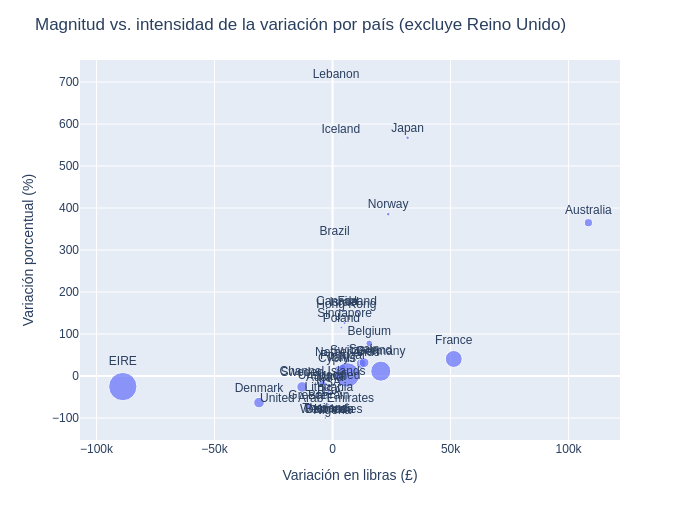

In [39]:
# Gráfico de dispersión
seg_pais_sin_uk = seg_pais.filter(pl.col("pais") != "United Kingdom")

fig = px.scatter(seg_pais_sin_uk.to_pandas(), x="variacion_gbp", y="variacion_pct",
                  size="P0", text="pais", hover_name="pais",
                  labels={"variacion_gbp": "Variación en libras (£)",
                          "variacion_pct": "Variación porcentual (%)", "P0": "Ingreso base P0"})
fig.update_traces(textposition="top center")
fig.update_layout(title="Magnitud vs. intensidad de la variación por país (excluye Reino Unido)",
                   height=520)
fig.show()


**Pregunta 6.1.** ¿Qué segmento se prioriza, con qué criterio, y en qué se diferencia de haber elegido el de mayor caída porcentual?

**Respuesta.** Se prioriza **EIRE**, con el criterio de contribución absoluta a la variación: su caída de £ 88 853.33 es la mayor de todo el conjunto de mercados fuera del Reino Unido. Elegir en cambio el de mayor caída porcentual habría llevado a priorizar los Emiratos Árabes Unidos (-77.82 %), un mercado que solo representaba £ 8 408.45 en P0: atender ese mercado primero habría dedicado esfuerzo comercial a una plaza cuya recuperación total apenas movería £ 6 543.67, trece veces menos dinero que EIRE.


---
## Informe de recomendación para el comité de inversiones de Brightwell Partners

**1. Lectura de la cifra de venta.** Los ingresos crecieron +£ 236 086.10 (+2.51 %) entre P0 y P1, pero las unidades cayeron -377 923 (-6.72 %) en el mismo periodo. Un negocio que vende menos unidades y factura más no está necesariamente mejorando: está cobrando distinto o vendiendo cosas distintas, y eso es exactamente lo que la descomposición del Bloque 4 aísla.

**2. Origen de la variación.** El componente de mayor magnitud es la entrada de productos nuevos al catálogo (+£ 2 046 903.92, 40.8 % del peso del puente), seguido por el efecto volumen del catálogo común, que es negativo (-£ 1 568 093.05, 31.3 %). Es decir: el catálogo que ya existía en ambos periodos vendió menos unidades, y ese deterioro fue compensado -no revertido- por productos que no existían en P0. Un crecimiento sostenido por altas de catálogo es estructuralmente distinto de uno sostenido por mejor desempeño del negocio ya instalado.

**3. Calidad de la base de clientes.** La retención al mes 6 cayó de 19.24 % en las cohortes del primer año a 15.66 % en las del segundo (-3.58 puntos porcentuales). Al mismo tiempo, el guardrail de concentración llegó a 34.35 % en un solo mes (enero de 2011), muy por encima del umbral de alerta declarado (30 %), y la tasa de cancelación promedió 15.58 % con picos de 18.37 %.

**4. Concentración geográfica del deterioro.** El mercado de EIRE explica, por sí solo, -£ 88 853.33 de variación negativa, la mayor caída en libras fuera del Reino Unido y trece veces el peso económico de la caída porcentual más pronunciada (Emiratos Árabes Unidos, -77.82 % sobre solo £ 8 408.45 de base).

**Decisión recomendada: adquirir bajo condiciones.** La cifra de crecimiento de ingresos es cierta, pero la evidencia reunida en este notebook muestra que ese crecimiento se apoya en la renovación del catálogo y no en la mejora del negocio ya instalado, mientras la calidad de la base de clientes se deteriora. Se recomienda condicionar la operación a: (a) un ajuste del precio de compra que refleje el descenso de retención documentado, o (b) un mecanismo de earn-out ligado a que la retención de las cohortes futuras no siga cayendo por debajo del nivel del segundo año observado.

**Riesgo principal de la recomendación.** El hallazgo más favorable del análisis -el crecimiento de ingresos- depende de que el negocio siga incorporando productos nuevos al ritmo observado en P1. Si esa capacidad de renovación de catálogo se detiene, el efecto volumen negativo del catálogo común (-£ 1 568 093.05) dejaría de estar compensado y los ingresos totales caerían, no solo las unidades.





## **Declaración de uso de inteligencia artificial**


Se utilizó Claude como apoyo para entender los códigos y resolver los ejercicios.
 Y de  esta forma ayudando a entender y comprender cada línea  de codigo antes de incorporarla al notebook.